## **Retail Strategy and Analytics Task**s

### **Load transaction data**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Excel file
data = pd.read_excel(r"C:\Users\ckats\Downloads\QVI_transaction_data.xlsx")

# Display the first 5 rows
data.head()


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


## Exploratory Data Analysis

In [9]:
# Convert the 'Date' column from Excel serial numbers to proper datetime
data['DATE'] = pd.to_datetime(data['DATE'], origin='1899-12-30', unit='D')

# Check the first few rows
print(data.head())

        DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0 2018-10-17          1            1000       1         5   
1 2019-05-14          1            1307     348        66   
2 2019-05-20          1            1343     383        61   
3 2018-08-17          2            2373     974        69   
4 2018-08-18          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  


In [6]:
# Shape of dataset
# Load Excel file 
data = pd.read_excel(r"C:\Users\ckats\Downloads\QVI_transaction_data.xlsx")
print("Rows:", data.shape[0], "Columns:", data.shape[1])

# Data types and non-null counts
data.info()

# Summary statistics
data.describe(include="all")


Rows: 264836 Columns: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            264836 non-null  datetime64[ns]
 1   STORE_NBR       264836 non-null  int64         
 2   LYLTY_CARD_NBR  264836 non-null  int64         
 3   TXN_ID          264836 non-null  int64         
 4   PROD_NBR        264836 non-null  int64         
 5   PROD_NAME       264836 non-null  object        
 6   PROD_QTY        264836 non-null  int64         
 7   TOT_SALES       264836 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 16.2+ MB


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836,264836.000000,264836.000000
unique,NaN,NaN,NaN,NaN,NaN,114,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,Kettle Mozzarella Basil & Pesto 175g,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,3304,NaN,NaN
mean,2018-12-30 00:52:12.879215616,135.08011,1.355495e+05,1.351583e+05,56.583157,NaN,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,NaN,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,NaN,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,NaN,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,NaN,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,NaN,200.000000,650.000000


In [19]:
# Count missing values per column
data.isnull().sum()

# Percentage of missing values
data.isnull().mean() * 100


DATE              0.0
STORE_NBR         0.0
LYLTY_CARD_NBR    0.0
TXN_ID            0.0
PROD_NBR          0.0
PROD_NAME         0.0
PROD_QTY          0.0
TOT_SALES         0.0
dtype: float64

In [21]:
# Count duplicates
data.duplicated().sum()

# Drop duplicates if necessary
data = data.drop_duplicates()


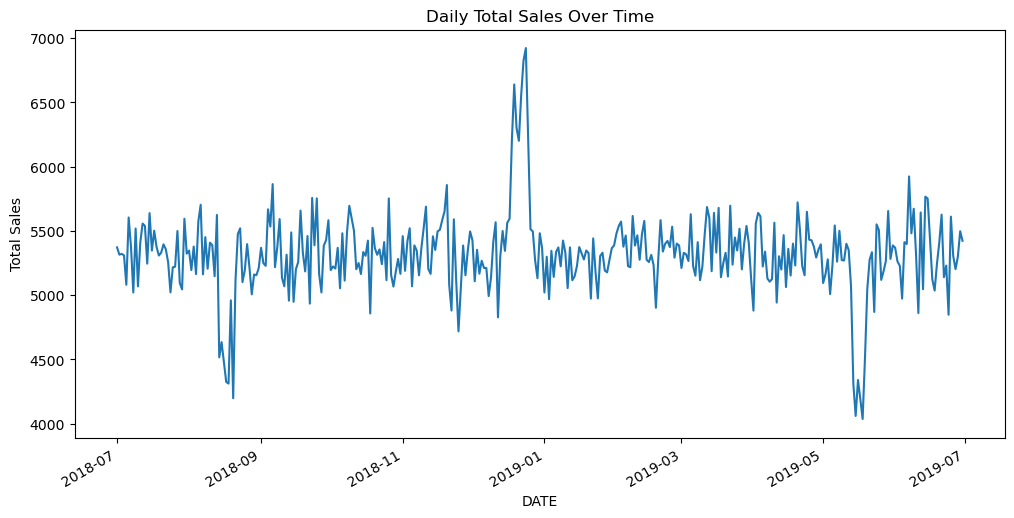

In [27]:
# Group sales by date
daily_sales = data.groupby('DATE')['TOT_SALES'].sum()

plt.figure(figsize=(12,6))
daily_sales.plot()
plt.title("Daily Total Sales Over Time")
plt.ylabel("Total Sales")
plt.show()


Key Insights 

Sales trends across 2018–2019 (slight decline overall).

Top-selling products (e.g., Doritos, Smiths, Kettle chips).

Store performance differences.

In [33]:
# Ensure DATE column is in datetime format (optional, for time-based analysis) 
data['DATE'] = pd.to_datetime(data['DATE'], errors='coerce') 
# Group by product name and sum sales
sales_by_product = data.groupby('PROD_NAME')['TOT_SALES'].sum().reset_index() 
# Sort products by sales (descending) 
sales_by_product = sales_by_product.sort_values(by='TOT_SALES', ascending=False) 
# Display the table
print(sales_by_product)

                                    PROD_NAME  TOT_SALES
11           Dorito Corn Chp     Supreme 380g    40352.0
86     Smiths Crnkle Chip  Orgnl Big Bag 380g    36367.6
77   Smiths Crinkle Chips Salt & Vinegar 330g    34804.2
33     Kettle Mozzarella   Basil & Pesto 175g    34457.4
76          Smiths Crinkle      Original 330g    34302.6
..                                        ...        ...
104          WW Crinkle Cut      Chicken 175g     4702.2
90   Sunbites Whlegrn    Crisps Frch/Onin 90g     4600.2
105         WW Crinkle Cut      Original 175g     4532.2
113            Woolworths Mild     Salsa 300g     4234.5
112            Woolworths Medium   Salsa 300g     4050.0

[114 rows x 2 columns]


#### **LOAD CUSTOMER DATA**

In [5]:
import pandas as pd
import numpy as np
# Load the CSV file
Customer = pd.read_csv(r"C:\Users\ckats\Downloads\QVI_purchase_behaviour (2).csv")

# Display the first 5 rows
data.head()


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


#### **MERGE TRANSACTION DATA AND CUSTOMER DATA**

In [50]:
import pandas as pd

# Load transaction data (Excel file)
data = pd.read_excel(r"C:\Users\ckats\Downloads\QVI_transaction_data.xlsx")

# Load customer purchase behaviour data (CSV file)
Customer = pd.read_csv(r"C:\Users\ckats\Downloads\QVI_purchase_behaviour (2).csv")

# Merge the two datasets on LYLTY_CARD_NBR
merged_df = pd.merge(
    data, 
    Customer, 
    on="LYLTY_CARD_NBR", 
    how="right"   # keep all rows from Customer, only matched rows from data
)

# Display the first 5 rows
merged_df.head()


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2018-09-16,1,1002,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,YOUNG SINGLES/COUPLES,Mainstream
2,2019-03-07,1,1003,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,YOUNG FAMILIES,Budget
3,2019-03-08,1,1003,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,YOUNG FAMILIES,Budget
4,2018-11-02,1,1004,5,96,WW Original Stacked Chips 160g,1,1.9,OLDER SINGLES/COUPLES,Mainstream


### **Summary Statistics**

In [53]:
# Summary statistics for numeric columns
merged_df.describe()

# Summary statistics including categorical columns
merged_df.describe(include="all")


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836,264836.000000,264836.000000,264836,264836
unique,NaN,NaN,NaN,NaN,NaN,114,NaN,NaN,7,3
top,NaN,NaN,NaN,NaN,NaN,Kettle Mozzarella Basil & Pesto 175g,NaN,NaN,OLDER SINGLES/COUPLES,Mainstream
freq,NaN,NaN,NaN,NaN,NaN,3304,NaN,NaN,54479,101988
mean,2018-12-30 00:52:12.879215360,135.08011,1.355495e+05,1.351583e+05,56.583157,NaN,1.907309,7.304200,NaN,NaN
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,NaN,1.000000,1.500000,NaN,NaN
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,NaN,2.000000,5.400000,NaN,NaN
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,NaN,2.000000,7.400000,NaN,NaN
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,NaN,2.000000,9.200000,NaN,NaN
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,NaN,200.000000,650.000000,NaN,NaN


### **Checking For Duplicates**

In [57]:
# Check duplicates 
merged_df.duplicated().sum()
# Drop duplicates 
merged_df = merged_df.drop_duplicates()

In [60]:
import pandas as pd

# Load transaction data (Excel file)
data = pd.read_excel(r"C:\Users\ckats\Downloads\QVI_transaction_data.xlsx")

# Load customer purchase behaviour data (CSV file)
Customer = pd.read_csv(r"C:\Users\ckats\Downloads\QVI_purchase_behaviour (2).csv")

# Merge using INNER JOIN (only matching rows)
merged_df = pd.merge(
    data, 
    Customer, 
    on="LYLTY_CARD_NBR", 
    how="inner"
)

# Display the first 5 rows
merged_df.head()


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


**Checking Missing values from merged dataset**

In [65]:
# Count missing values per column
merged_df.isnull().sum()

# Percentage of missing values per column
merged_df.isnull().mean() * 100


DATE                0.0
STORE_NBR           0.0
LYLTY_CARD_NBR      0.0
TXN_ID              0.0
PROD_NBR            0.0
PROD_NAME           0.0
PROD_QTY            0.0
TOT_SALES           0.0
LIFESTAGE           0.0
PREMIUM_CUSTOMER    0.0
dtype: float64

### **Check for Inconsistencies**

In [69]:
# Check data types
merged_df.dtypes

# Find duplicate rows
merged_df.duplicated().sum()

# Example: check for negative or zero sales (if not expected)
merged_df[merged_df['TOT_SALES'] <= 0]

# Example: check unique values in categorical columns
merged_df['LIFESTAGE'].unique()
merged_df['PREMIUM_CUSTOMER'].unique()


array(['Premium', 'Budget', 'Mainstream'], dtype=object)

### **Detect Outliers**

In [73]:
# IQR method for TOT_SALES
Q1 = merged_df['TOT_SALES'].quantile(0.25)
Q3 = merged_df['TOT_SALES'].quantile(0.75)
IQR = Q3 - Q1

outliers = merged_df[(merged_df['TOT_SALES'] < (Q1 - 1.5 * IQR)) | 
                     (merged_df['TOT_SALES'] > (Q3 + 1.5 * IQR))]

outliers.head()


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
11,2018-08-20,8,8294,8221,114,Kettle Sensations Siracha Lime 150g,5,23.0,MIDAGE SINGLES/COUPLES,Budget
56,2019-05-16,74,74336,73182,84,GrnWves Plus Btroot & Chilli Jam 180g,5,15.5,MIDAGE SINGLES/COUPLES,Budget
72,2018-08-19,96,96203,96025,7,Smiths Crinkle Original 330g,5,28.5,MIDAGE SINGLES/COUPLES,Budget
100,2019-05-20,130,130108,134125,2,Cobs Popd Sour Crm &Chives Chips 110g,5,19.0,MIDAGE SINGLES/COUPLES,Budget


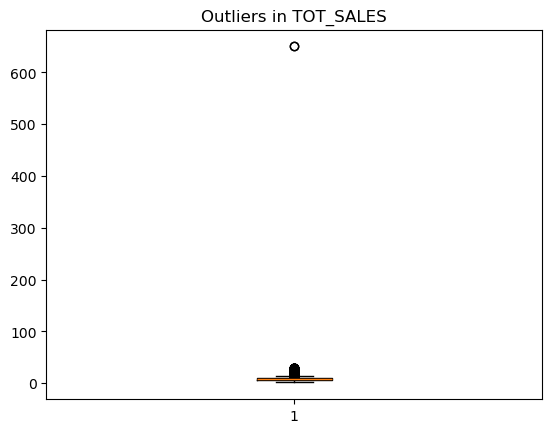

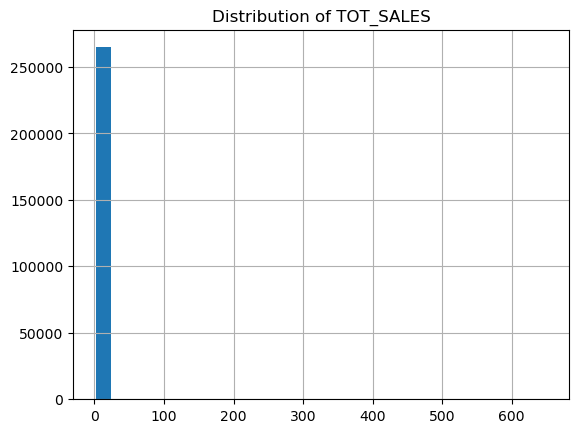

In [79]:
import matplotlib.pyplot as plt

# Boxplot for outliers
plt.boxplot(merged_df['TOT_SALES'])
plt.title("Outliers in TOT_SALES")
plt.show()

# Histogram for distribution
merged_df['TOT_SALES'].hist(bins=30)
plt.title("Distribution of TOT_SALES")
plt.show()


# <span style="font-size:20pt; color:black">Total Sales by year</span>

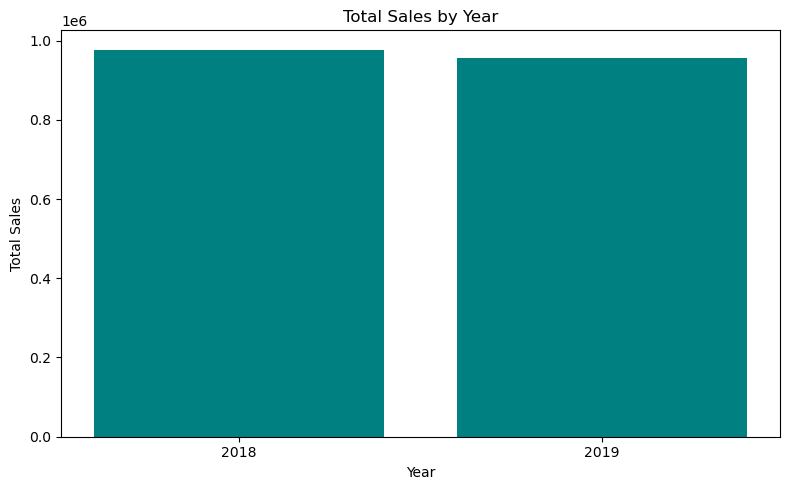

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure DATE column is in datetime format
merged_df['DATE'] = pd.to_datetime(merged_df['DATE'], errors='coerce')

# Extract year from DATE
merged_df['YEAR'] = merged_df['DATE'].dt.year

# Group by YEAR and sum sales
sales_by_year = merged_df.groupby('YEAR')['TOT_SALES'].sum().reset_index()

# Plot bar chart
plt.figure(figsize=(8,5))
plt.bar(sales_by_year['YEAR'], sales_by_year['TOT_SALES'], color='teal')

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Total Sales by Year")
plt.xticks(sales_by_year['YEAR'])  # show each year clearly
plt.tight_layout()
plt.show()


**Total Sales by Year**

In [85]:
import pandas as pd

# Load transaction data
data = pd.read_excel(r"C:\Users\ckats\Downloads\QVI_transaction_data.xlsx")

# Ensure DATE column is datetime
data['DATE'] = pd.to_datetime(data['DATE'], errors='coerce')

# Extract year
data['YEAR'] = data['DATE'].dt.year

# Group by YEAR and sum sales
sales_by_year = data.groupby('YEAR')['TOT_SALES'].sum().reset_index()

# Rename columns for clarity
sales_by_year.columns = ['Year', 'Total_Sales']

# Display table
print(sales_by_year)


   Year  Total_Sales
0  2018    977091.15
1  2019    957323.85


# <span style="font-size:20pt; color:black">Trends of Sales in 2018 and 2019</span>

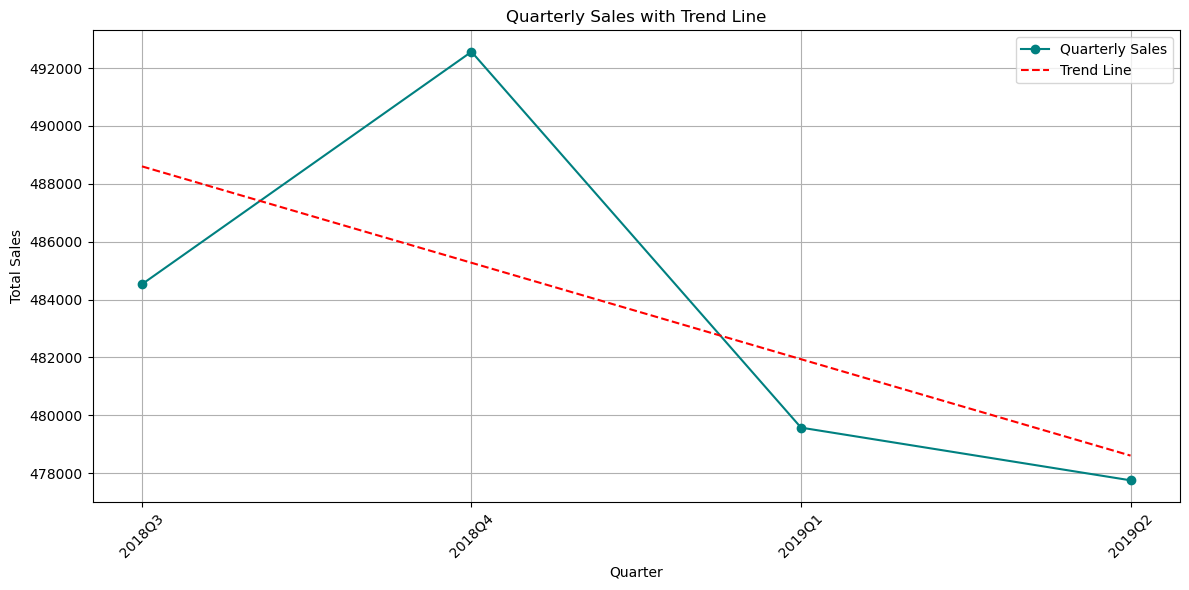

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load transaction data
data = pd.read_excel(r"C:\Users\ckats\Downloads\QVI_transaction_data.xlsx")

# Ensure DATE column is datetime
data['DATE'] = pd.to_datetime(data['DATE'], errors='coerce')

# Create a Quarter column (Year + Quarter)
data['Quarter'] = data['DATE'].dt.to_period('Q')

# Group by Quarter and sum sales
sales_by_quarter = data.groupby('Quarter')['TOT_SALES'].sum().reset_index()

# Convert Quarter to string for plotting
sales_by_quarter['Quarter'] = sales_by_quarter['Quarter'].astype(str)

# Create numeric index for regression
x = np.arange(len(sales_by_quarter))
y = sales_by_quarter['TOT_SALES'].values

# Fit linear regression (trend line)
coeffs = np.polyfit(x, y, 1)
trend = np.poly1d(coeffs)

# Plot actual sales
plt.figure(figsize=(12,6))
plt.plot(sales_by_quarter['Quarter'], y, marker='o', color='teal', label='Quarterly Sales')

# Plot trend line
plt.plot(sales_by_quarter['Quarter'], trend(x), color='red', linestyle='--', label='Trend Line')

# Add labels and title
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.title("Quarterly Sales with Trend Line")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Insights**

Sales dropped slightly from ₹977k in 2018 to ₹957k in 2019, a 2.02% decline.

This indicates stability with a minor downward adjustment, rather than a sharp fall.

The trend line shows a slight downward slope, confirming that overall sales were tapering off rather than growing.

The quarterly line chart likely shows fluctuations within each year, but the regression line smooths this into a gentle decline trend.

# <span style="font-size:20pt; color:teal">Top 10 Product Names by Sales</span>

In [101]:
import pandas as pd

# Load transaction data
data = pd.read_excel(r"C:\Users\ckats\Downloads\QVI_transaction_data.xlsx")

# Ensure DATE column is datetime
data['DATE'] = pd.to_datetime(data['DATE'], errors='coerce')

# Group by product name and sum sales
sales_by_product = data.groupby('PROD_NAME')['TOT_SALES'].sum().reset_index()

# Sort products by sales (descending)
sales_by_product = sales_by_product.sort_values(by='TOT_SALES', ascending=False)

# Select top 10
top10_products = sales_by_product.head(10)

# Display table
print(top10_products)


                                   PROD_NAME  TOT_SALES
11          Dorito Corn Chp     Supreme 380g    40352.0
86    Smiths Crnkle Chip  Orgnl Big Bag 380g    36367.6
77  Smiths Crinkle Chips Salt & Vinegar 330g    34804.2
33    Kettle Mozzarella   Basil & Pesto 175g    34457.4
76         Smiths Crinkle      Original 330g    34302.6
6                       Cheezels Cheese 330g    34296.9
12          Doritos Cheese      Supreme 330g    33390.6
39   Kettle Sweet Chilli And Sour Cream 175g    33031.8
34                      Kettle Original 175g    32740.2
35      Kettle Sea Salt     And Vinegar 175g    32589.0


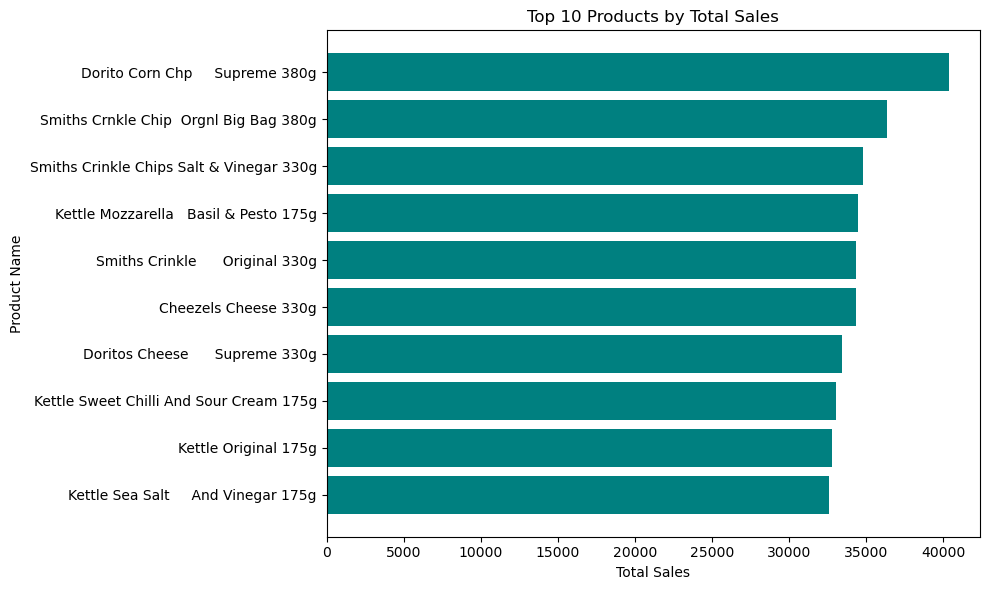

In [103]:
import pandas as pd
import matplotlib.pyplot as plt

# Load transaction data
data = pd.read_excel(r"C:\Users\ckats\Downloads\QVI_transaction_data.xlsx")

# Ensure DATE column is datetime
data['DATE'] = pd.to_datetime(data['DATE'], errors='coerce')

# Group by product name and sum sales
sales_by_product = data.groupby('PROD_NAME')['TOT_SALES'].sum().reset_index()

# Sort products by sales (descending)
sales_by_product = sales_by_product.sort_values(by='TOT_SALES', ascending=False)

# Select top 10 products
top10_products = sales_by_product.head(10)

# Plot horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(top10_products['PROD_NAME'], top10_products['TOT_SALES'], color='teal')

# Invert y-axis so highest sales appear at the top
plt.gca().invert_yaxis()

# Add labels and title
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.title("Top 10 Products by Total Sales")
plt.tight_layout()
plt.show()


# <span style="font-size:22pt; color:salmon">Bottom 10 Product_Name by Sales</span>


                                    PROD_NAME  TOT_SALES
112            Woolworths Medium   Salsa 300g     4050.0
113            Woolworths Mild     Salsa 300g     4234.5
105         WW Crinkle Cut      Original 175g     4532.2
90   Sunbites Whlegrn    Crisps Frch/Onin 90g     4600.2
104          WW Crinkle Cut      Chicken 175g     4702.2
89       Snbts Whlgrn Crisps Cheddr&Mstrd 90g     5076.2
111            Woolworths Cheese   Rings 190g     5169.6
106         WW D/Style Chip     Sea Salt 200g     5249.7
109    WW Sour Cream &OnionStacked Chips 160g     5323.8
108            WW Original Stacked Chips 160g     5323.8


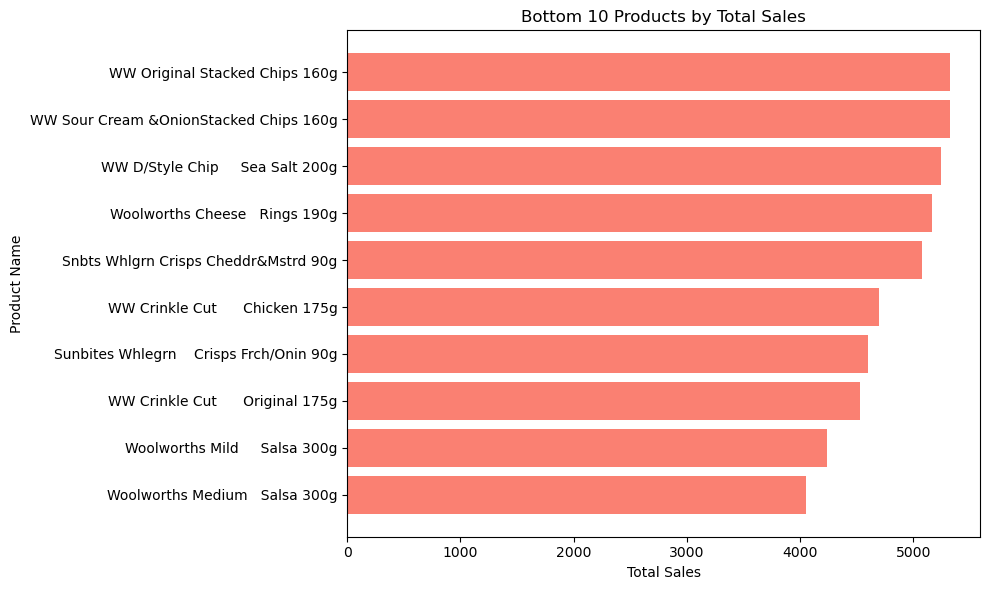

In [106]:
import pandas as pd
import matplotlib.pyplot as plt

# Load transaction data
data = pd.read_excel(r"C:\Users\ckats\Downloads\QVI_transaction_data.xlsx")

# Ensure DATE column is datetime
data['DATE'] = pd.to_datetime(data['DATE'], errors='coerce')

# Group by product name and sum sales
sales_by_product = data.groupby('PROD_NAME')['TOT_SALES'].sum().reset_index()

# Sort products by sales ascending
sales_by_product = sales_by_product.sort_values(by='TOT_SALES', ascending=True)

# Select bottom 10 products
bottom10_products = sales_by_product.head(10)

# Display table
print(bottom10_products)

# Plot horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(bottom10_products['PROD_NAME'], bottom10_products['TOT_SALES'], color='salmon')

# Add labels and title
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.title("Bottom 10 Products by Total Sales")
plt.tight_layout()
plt.show()


# <span style="font-size:20pt; color:teal">Lifestage By Sum of Sales</span>

In [112]:
import pandas as pd

# Assuming merged_df is already created by merging transaction + customer data
# Group by LIFESTAGE and sum sales
sales_by_lifestage = merged_df.groupby('LIFESTAGE')['TOT_SALES'].sum().reset_index()

# Rename columns for clarity
sales_by_lifestage.columns = ['Lifestage', 'Total_Sales']

# Display table
print(sales_by_lifestage)


                Lifestage  Total_Sales
0  MIDAGE SINGLES/COUPLES    184751.30
1            NEW FAMILIES     50433.45
2          OLDER FAMILIES    353767.20
3   OLDER SINGLES/COUPLES    402426.75
4                RETIREES    366470.90
5          YOUNG FAMILIES    316160.10
6   YOUNG SINGLES/COUPLES    260405.30


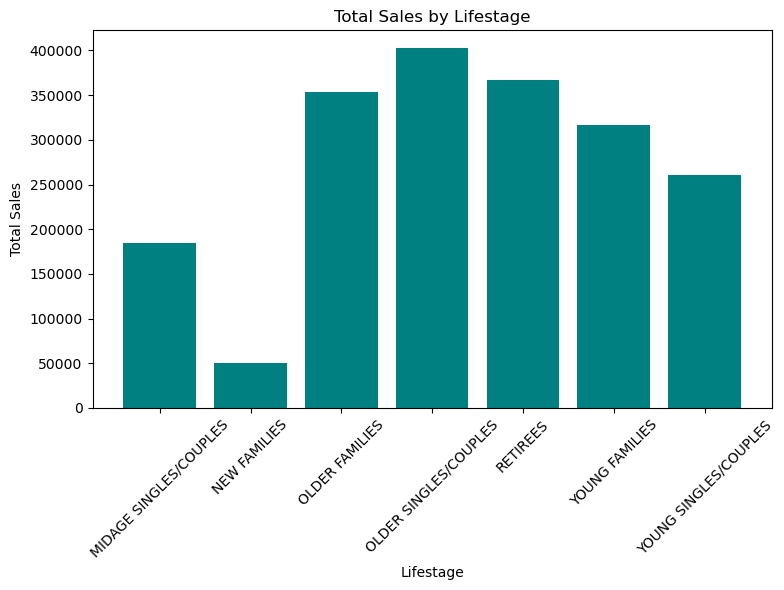

In [114]:
import matplotlib.pyplot as plt

# Plot column chart
plt.figure(figsize=(8,6))
plt.bar(sales_by_lifestage['Lifestage'], sales_by_lifestage['Total_Sales'], color='teal')

# Add labels and title
plt.xlabel("Lifestage")
plt.ylabel("Total Sales")
plt.title("Total Sales by Lifestage")
plt.xticks(rotation=45)  # rotate labels for readability
plt.tight_layout()
plt.show()


# <span style="font-size:20pt; color:teal">Total Sales By Premium Customer</span>

In [118]:
import pandas as pd

# Group by PREMIUM_CUSTOMER and sum sales
sales_by_premium = merged_df.groupby('PREMIUM_CUSTOMER')['TOT_SALES'].sum().reset_index()

# Rename columns for clarity
sales_by_premium.columns = ['Premium_Customer', 'Total_Sales']

# Display table
print(sales_by_premium)


  Premium_Customer  Total_Sales
0           Budget    676211.55
1       Mainstream    750744.50
2          Premium    507458.95


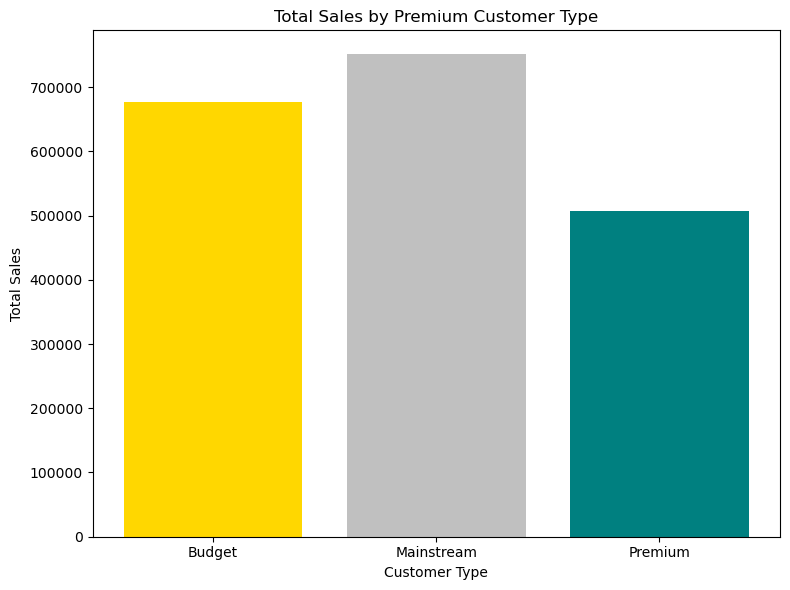

In [120]:
import matplotlib.pyplot as plt

# Plot column chart
plt.figure(figsize=(8,6))
plt.bar(sales_by_premium['Premium_Customer'], sales_by_premium['Total_Sales'], color=['gold','silver','teal'])

# Add labels and title
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")
plt.title("Total Sales by Premium Customer Type")
plt.tight_layout()
plt.show()


# <span style="font-size:20pt; color:black">Total Sales by Lifestages and Premium Customer</span>

In [122]:
import pandas as pd

# Assuming merged_df is your merged dataset (transactions + customer data)
pivot_data = merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()

# Create pivot table
pivot_table = pivot_data.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='TOT_SALES').fillna(0)

# Display table
print(pivot_table)


PREMIUM_CUSTOMER           Budget  Mainstream    Premium
LIFESTAGE                                               
MIDAGE SINGLES/COUPLES   35514.80    90803.85   58432.65
NEW FAMILIES             21928.45    17013.90   11491.10
OLDER FAMILIES          168363.25   103445.55   81958.40
OLDER SINGLES/COUPLES   136769.80   133393.80  132263.15
RETIREES                113147.80   155677.05   97646.05
YOUNG FAMILIES          139345.85    92788.75   84025.50
YOUNG SINGLES/COUPLES    61141.60   157621.60   41642.10


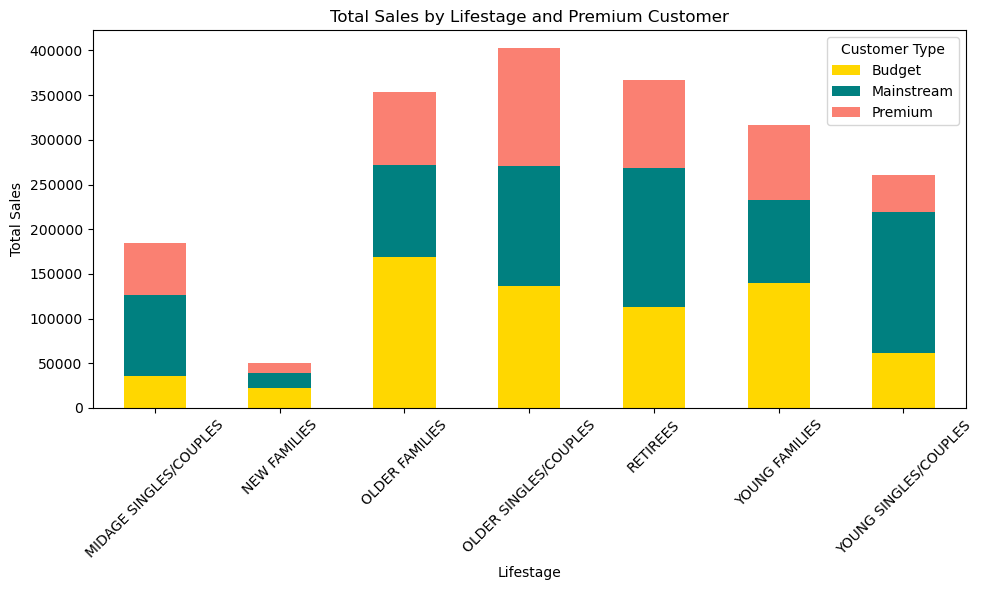

In [124]:
import matplotlib.pyplot as plt

# Plot stacked column chart
pivot_table.plot(kind='bar', stacked=True, figsize=(10,6), color=['gold','teal','salmon'])

# Add labels and title
plt.xlabel("Lifestage")
plt.ylabel("Total Sales")
plt.title("Total Sales by Lifestage and Premium Customer")
plt.xticks(rotation=45)
plt.legend(title="Customer Type")
plt.tight_layout()
plt.show()


# <span style="font-size:20pt; color:black">Percentage Contribution of Premium Customer Types by Lifestages</span>

In [140]:
import pandas as pd

# Group by Lifestage and Premium Customer, then sum sales
pivot_data = merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()

# Create pivot table
pivot_table = pivot_data.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='TOT_SALES').fillna(0)

# Normalize to percentages (row-wise)
pivot_table_percent = pivot_table.div(pivot_table.sum(axis=1), axis=0) * 100

# Round to 2 decimal places
pivot_table_percent = pivot_table_percent.round(2)

# Format as string with % sign
pivot_table_percent = pivot_table_percent.astype(str) + '%'

# Display table
print(pivot_table_percent)


PREMIUM_CUSTOMER        Budget Mainstream Premium
LIFESTAGE                                        
MIDAGE SINGLES/COUPLES  19.22%     49.15%  31.63%
NEW FAMILIES            43.48%     33.74%  22.78%
OLDER FAMILIES          47.59%     29.24%  23.17%
OLDER SINGLES/COUPLES   33.99%     33.15%  32.87%
RETIREES                30.87%     42.48%  26.64%
YOUNG FAMILIES          44.07%     29.35%  26.58%
YOUNG SINGLES/COUPLES   23.48%     60.53%  15.99%


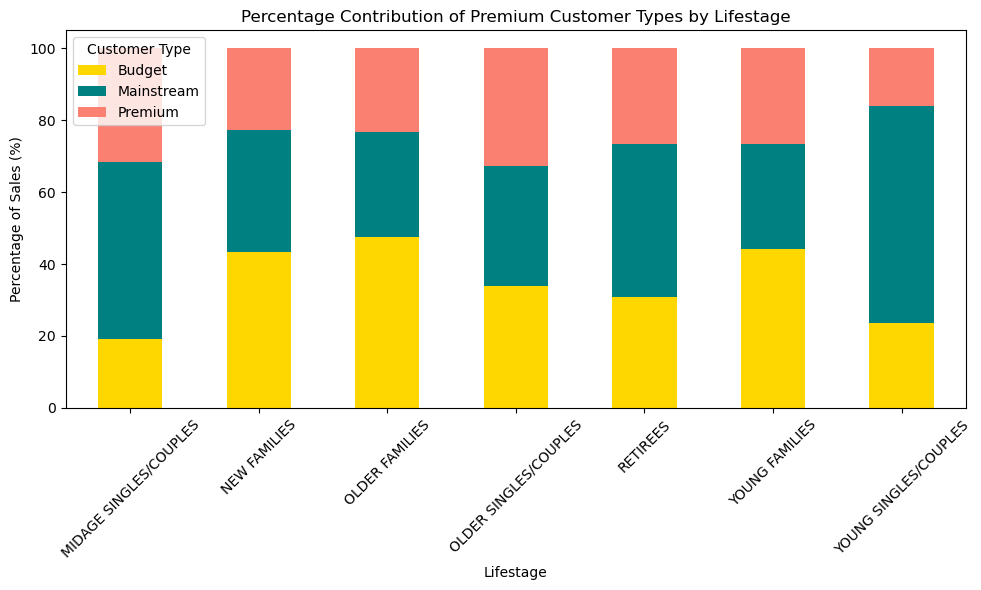

In [136]:
import matplotlib.pyplot as plt

# Plot 100% stacked bar chart
pivot_table_percent.plot(kind='bar', stacked=True, figsize=(10,6), color=['gold','teal','salmon'])

# Add labels and title
plt.xlabel("Lifestage")
plt.ylabel("Percentage of Sales (%)")
plt.title("Percentage Contribution of Premium Customer Types by Lifestage")
plt.xticks(rotation=45)
plt.legend(title="Customer Type")
plt.tight_layout()
plt.show()
